# SDV Models: Comprehensive Evaluation — Adult Census Income

This notebook evaluates four synthetic data generation models on the **Adult Census Income** dataset (`Datasets/adult_census.csv`):
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using:
- **Fidelity** metrics: KS complement, Wasserstein distance, JS divergence, Gower distance, MMD, cosine similarity, ANN distance
- **Utility** metrics: TSTR/TRTR with 10 classifiers (AUC, Accuracy, F1, Precision, Recall, PR-AUC)
- **Structural** analysis: bivariate Δ-correlation, t-SNE, PCA + clustering
- **Privacy** assessment: Cosine + Hungarian mapping, Mahalanobis matching

**Target variable**: `income` (binary: `<=50K` / `>=50K`)


## 1. Data Loading and Setup


In [1]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Locate adult_census.csv (works when run from Notebooks/ or project root)
_csv_paths = [
    'Datasets/adult_census.csv',
    '../Datasets/adult_census.csv',
]
csv_path = next((p for p in _csv_paths if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError('adult_census.csv not found. Expected in Datasets/ or ../Datasets/')

adult_data = pd.read_csv(csv_path)

# Normalize column names (some versions use different names)
adult_data = adult_data.rename(columns={
    'gender': 'sex',
    'educational-num': 'education-num',
})

# Strip leading/trailing whitespace from string columns
data = adult_data.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# Replace '?' with NaN (Adult dataset missing-value marker)
data = adult_data.replace('?', np.nan)

if 'income' not in data.columns:
    raise KeyError("Column 'income' not found in dataset")

# Normalise income labels: strip trailing dot, map >50K -> >=50K
data['income'] = (
    data['income']
    .astype(str)
    .str.replace(r'\.$', '', regex=True)
    .replace({'>50K': '>=50K', '<=50K': '<=50K'})
)

print('Data shape:', data.shape)
print('Columns:', list(data.columns))
print('\nIncome distribution:')
print(data['income'].value_counts(dropna=False))
print('\nMissing values per column:')
print(data.isnull().sum()[data.isnull().sum() > 0])

Data shape: (48842, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Income distribution:
income
<=50K    37155
>=50K    11687
Name: count, dtype: int64

Missing values per column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


## 2. Sample + SDV Metadata


In [2]:
# Adult Census: train SDV models, evaluate, and compare
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sdv.metadata import SingleTableMetadata
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# -----------------------------
# 1) Prepare Adult Census data
# -----------------------------
adult_data = data.copy()

# Ensure target column exists
target_col = "income"
if target_col not in adult_data.columns:
    raise KeyError(f"Column '{target_col}' not found in data")

# Normalize common Adult income labels (handles train/test variants)
adult_data[target_col] = (
    adult_data[target_col]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)  # removes trailing dot in test split labels
    .replace({">50K": ">=50K", "<=50K": "<=50K", ">=50K": ">=50K"})
)

# Optional: drop rows with missing target (if any)
adult_data = adult_data.dropna(subset=[target_col]).reset_index(drop=True)

# -----------------------------
# 2) Build metadata
# -----------------------------
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(adult_data)

# Force target to categorical for Adult Census classification task
metadata.update_column(column_name=target_col, sdtype="categorical")

# -----------------------------
# 3) Define and train models
# -----------------------------
n_samples = len(adult_data)  # match real dataset size (change if needed)

models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata, enforce_rounding=True),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata, enforce_rounding=True),
    "TVAE": TVAESynthesizer(metadata=metadata, enforce_rounding=True),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata, enforce_rounding=True),
}

synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(adult_data)

    synthetic_data = model.sample(num_rows=n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=adult_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data=adult_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()

    summary.append(
        {
            "Model": name,
            "Diagnostic Score": diag_score,
            "Quality Score": qual_score,
            "Rows Generated": len(synthetic_data),
        }
    )

# -----------------------------
# 4) Compare models
# -----------------------------
summary_df = pd.DataFrame(summary).sort_values(
    by="Quality Score", ascending=False
).reset_index(drop=True)

print("\nModel comparison (Adult Census):")
display(summary_df)

best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]

print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 77.21it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 75.29it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 16.26it/s]|
Column Shapes Score: 89.82%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:03<00:00, 31.64it/s]|
Column Pair Trends Score: 87.56%

Overall Score (Average): 88.69%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 247.34it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 378.72it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 37.26it/s]|
Column Shapes Score: 93.22%

(2/2) Evalu

,Model,Diagnostic Score,Quality Score,Rows Generated
0,TVAE,1.0,0.910348,48842
1,CopulaGAN,1.0,0.903951,48842
2,CTGAN,1.0,0.886921,48842
3,GaussianCopula,1.0,0.821502,48842



Best model by quality score: TVAE


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,37,Private,201661,Bachelors,13,Divorced,Sales,Unmarried,Black,Male,0,0,30,United-States,<=50K
1,37,Private,204366,HS-grad,9,Never-married,Prof-specialty,Not-in-family,White,Male,2,0,40,United-States,<=50K
2,41,Local-gov,91582,Assoc-acdm,12,Married-civ-spouse,Adm-clerical,Wife,White,Female,9,0,20,United-States,<=50K
3,29,Private,288494,HS-grad,10,Never-married,Transport-moving,Not-in-family,White,Male,7049,0,48,United-States,<=50K
4,34,Private,80929,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K


# 1. Univariate Analysis
#### 1.1. Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 50.58it/s]|
Column Shapes Score: 89.66%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 95.63it/s]| 
Column Pair Trends Score: 87.78%

Overall Score (Average): 88.72%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 34.07it/s]|
Column Shapes Score: 92.94%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 91.05it/s]| 
Column Pair Trends Score: 85.51%

Overall Score (Average): 89.22%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 41.82it/s]|
Column Shapes Score: 90.76%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:01<00:00, 71.58it/s]|
Column Pair Trends Score: 89.72%

Overall Score (Average): 90.24%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 53.83it/s]|
Column Shapes Score: 88.25%

(2/2) Evaluating Column Pair Trends

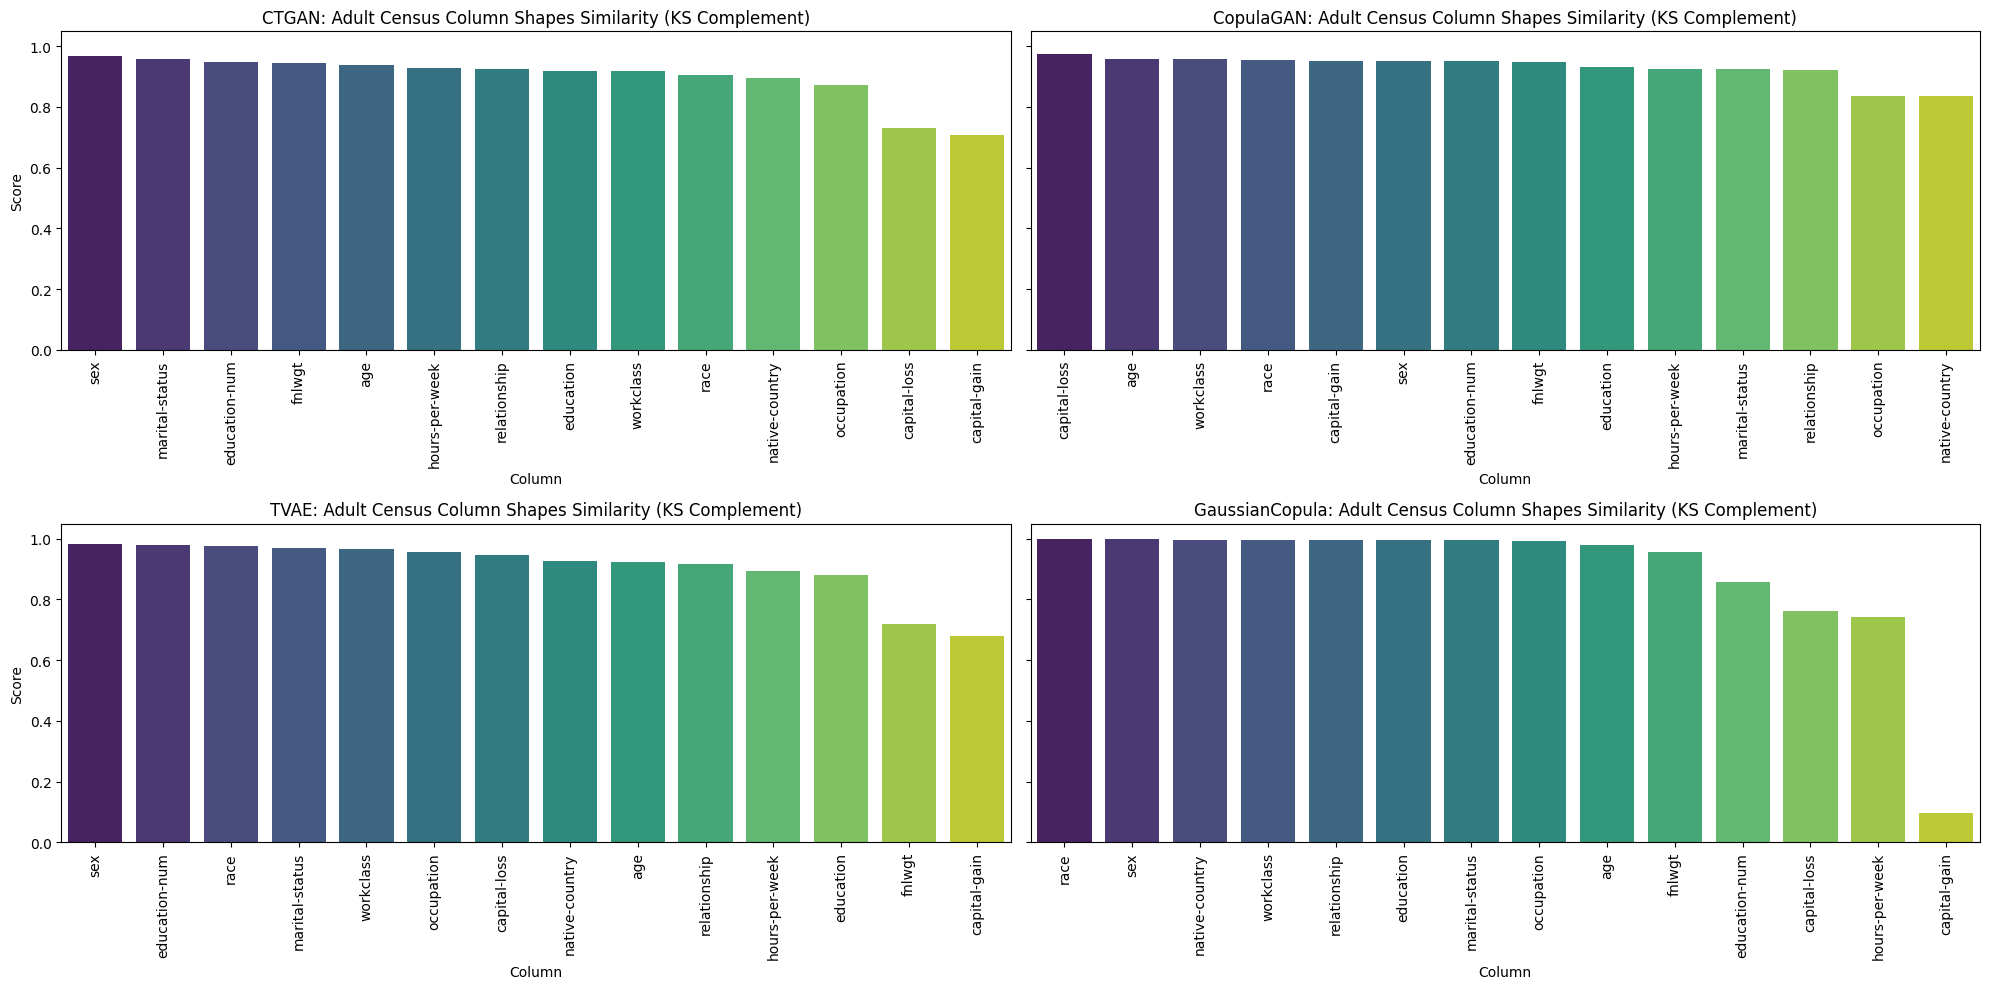

,Column,Metric,Score,Model
0,sex,TVComplement,0.967098,CTGAN
1,marital-status,TVComplement,0.958028,CTGAN
2,education-num,KSComplement,0.946562,CTGAN
3,fnlwgt,KSComplement,0.943389,CTGAN
4,age,KSComplement,0.936673,CTGAN
5,hours-per-week,KSComplement,0.929221,CTGAN
6,relationship,TVComplement,0.924819,CTGAN
7,education,TVComplement,0.917428,CTGAN
8,workclass,TVComplement,0.917064,CTGAN
9,race,TVComplement,0.906126,CTGAN


In [3]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Keep only models that actually exist in synthetic_datasets
preferred_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
model_order = [m for m in preferred_order if m in synthetic_datasets]

target_col = "income"  # Adult Census target column

# Real data for quality evaluation (exclude target for feature-shape comparison)
real_eval = data.drop(columns=[target_col], errors="ignore").copy()

# Build metadata from real evaluation frame
metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()

    # Exclude target for like-to-like feature distribution comparison
    synth_eval = synth_df.drop(columns=[target_col], errors="ignore")

    # Align columns safely with real_eval
    missing_cols = [c for c in real_eval.columns if c not in synth_eval.columns]
    if missing_cols:
        print(f"Skipping {model_name}: missing columns -> {missing_cols}")
        continue

    synth_eval = synth_eval[real_eval.columns]

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )

    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

# Plot only models that were successfully evaluated
valid_models = list(column_shape_details.keys())

if not valid_models:
    raise ValueError("No models could be evaluated. Check synthetic_datasets column compatibility.")

n = len(valid_models)
rows = (n + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(20, 5 * rows), sharey=True)
axes = axes.flatten()

for i, model_name in enumerate(valid_models):
    ax = axes[i]
    details = column_shape_details[model_name]

    sns.barplot(
        x="Column",
        y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Adult Census Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

# Hide any unused subplot axes
for j in range(len(valid_models), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)

display(combined_details.head(20))

#### 1.2. Jensen–Shannon divergence

In [4]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

In [5]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes these already exist:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]

    # Ensure same column order as real data
    synth_df = synth_df[data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in data.columns:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

# Summary table (lower is better)
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot all 4 models in one figure
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'State-gov'

#### 1.3 Wasserstein Distance


CTGAN - Wasserstein Distance (per engineered feature):
age: 0.016840
fnlwgt: 0.007100
education-num: 0.017534
capital-gain: 0.003076
capital-loss: 0.015365
hours-per-week: 0.012802
workclass_Federal-gov: 0.014598
workclass_Local-gov: 0.008722
workclass_Never-worked: 0.004300
workclass_Private: 0.111461
workclass_Self-emp-inc: 0.061074
workclass_Self-emp-not-inc: 0.011629
workclass_State-gov: 0.011588
workclass_Without-pay: 0.005241
workclass_nan: 0.011752
education_10th: 0.005753
education_11th: 0.002600
education_12th: 0.003952
education_1st-4th: 0.010728
education_5th-6th: 0.011056
education_7th-8th: 0.006572
education_9th: 0.002928
education_Assoc-acdm: 0.004156
education_Assoc-voc: 0.001228
education_Bachelors: 0.007862
education_Doctorate: 0.010380
education_HS-grad: 0.021969
education_Masters: 0.005200
education_Preschool: 0.005405
education_Prof-school: 0.003194
education_Some-college: 0.025265
marital-status_Divorced: 0.009254
marital-status_Married-AF-spouse: 0.007453
marital

,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,GaussianCopula,0.006071,0.000317,0.360021
1,TVAE,0.010608,0.004023,0.093813
2,CTGAN,0.014904,0.005323,0.111461
3,CopulaGAN,0.014979,0.005129,0.172413


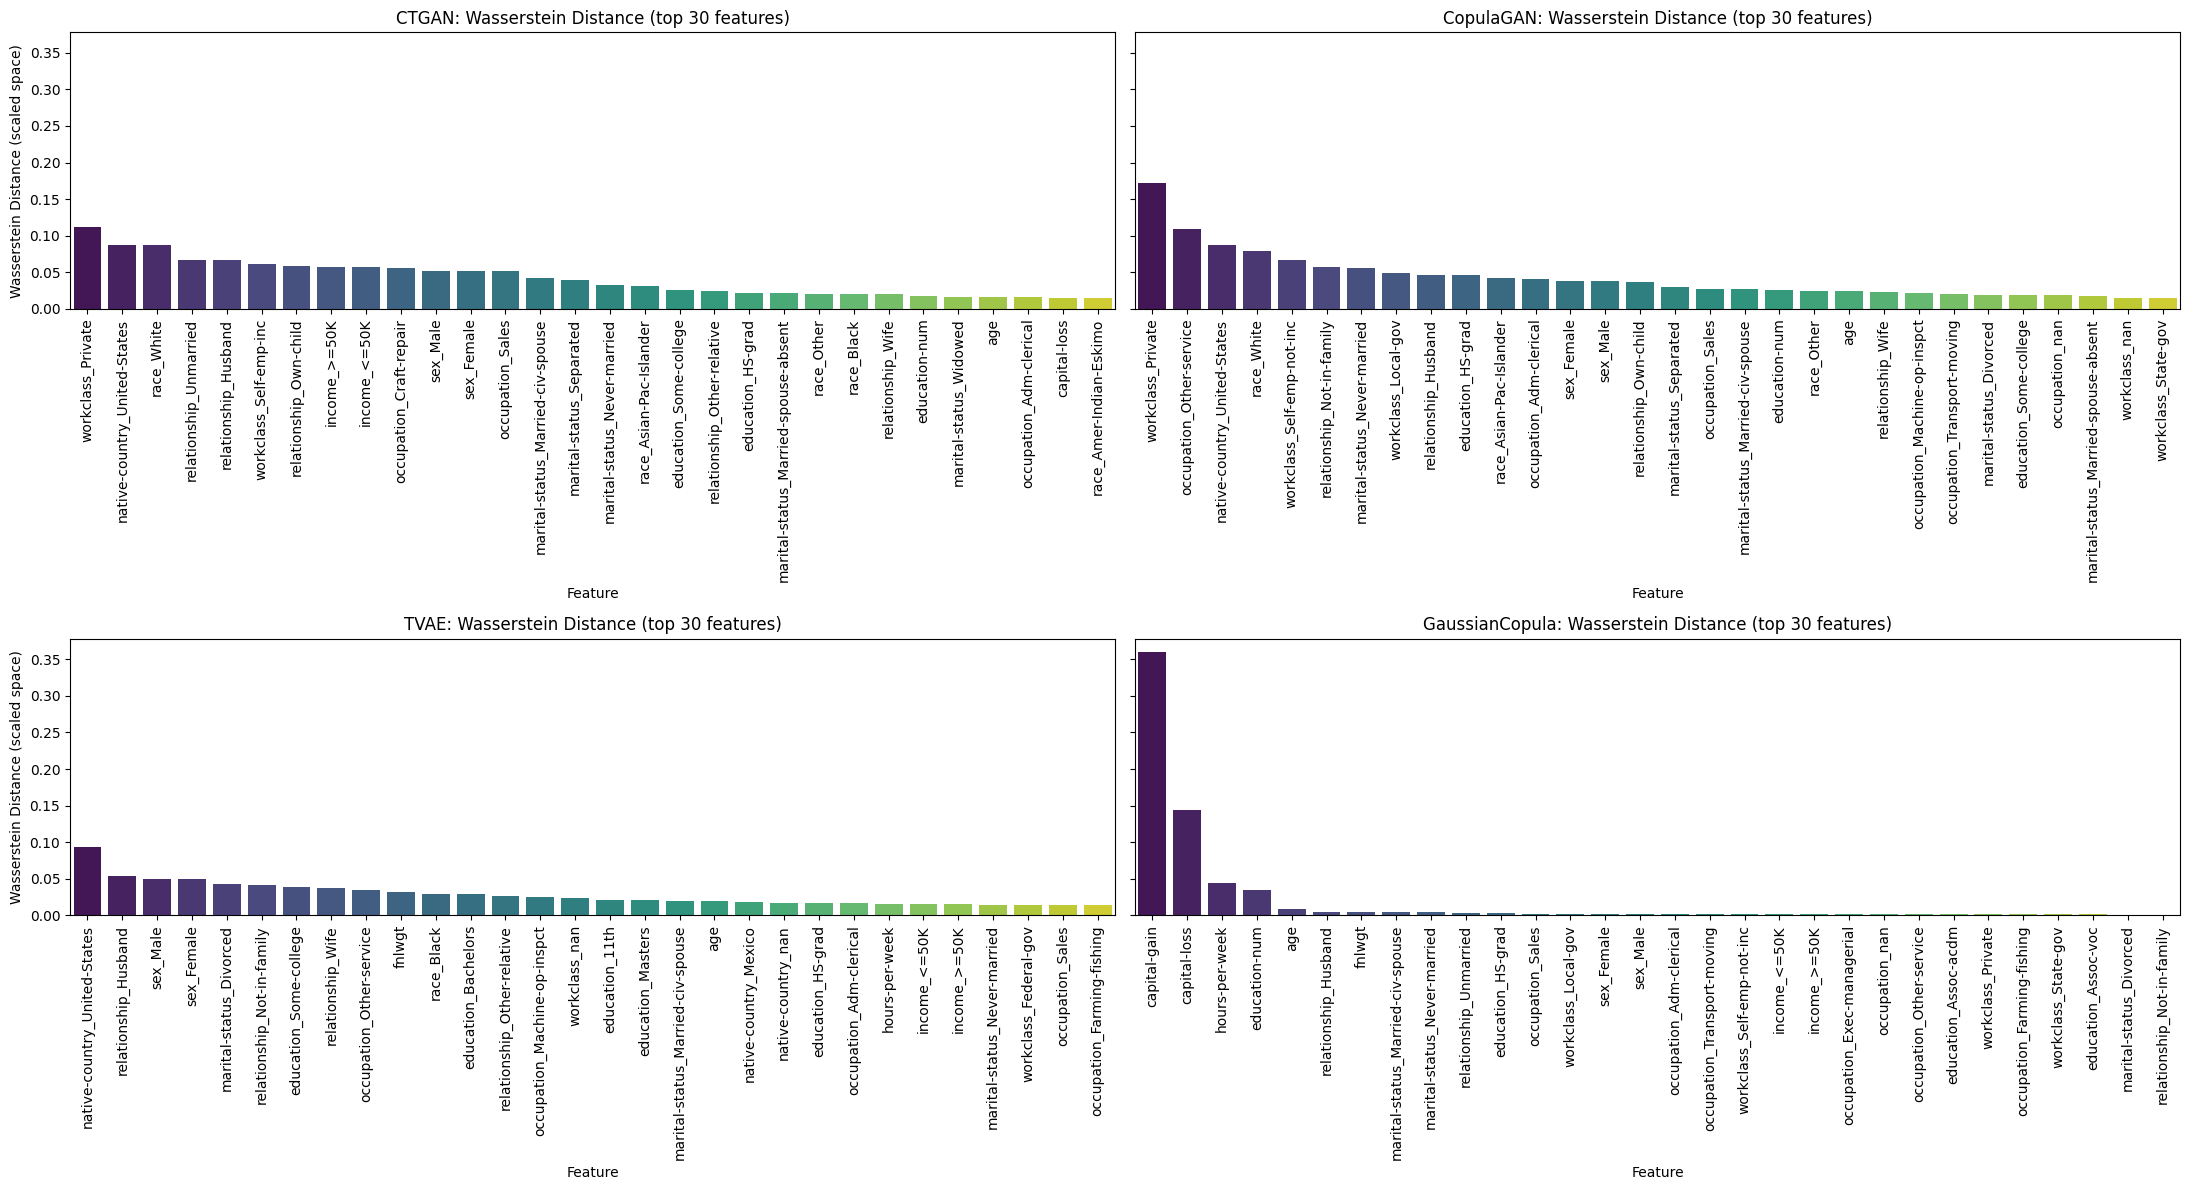

In [ ]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes these already exist:
# - data: pd.DataFrame (real)
# - synthetic_datasets: dict[str, pd.DataFrame]

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# ---- helpers ----
def _align_columns(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    common = [c for c in real_df.columns if c in synth_df.columns]
    missing_in_synth = [c for c in real_df.columns if c not in synth_df.columns]
    missing_in_real = [c for c in synth_df.columns if c not in real_df.columns]

    if missing_in_synth:
        print(f"Warning: synthetic missing {len(missing_in_synth)} columns present in real; dropping from real for comparison.")
    if missing_in_real:
        print(f"Warning: synthetic has {len(missing_in_real)} columns not in real; dropping from synthetic for comparison.")

    r = real_df[common].copy()
    s = synth_df[common].copy()
    return r, s


def _build_feature_matrix_for_wasserstein(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns two aligned numeric matrices with identical columns:
    - numeric columns passed through as float
    - categorical columns one-hot encoded using categories observed in real
    """
    num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in real_df.columns if c not in num_cols]

    parts_r = []
    parts_s = []

    if num_cols:
        r_num = real_df[num_cols].apply(pd.to_numeric, errors="coerce").astype(float)
        s_num = synth_df[num_cols].apply(pd.to_numeric, errors="coerce").astype(float)
        parts_r.append(r_num)
        parts_s.append(s_num)

    if cat_cols:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        r_cat = ohe.fit_transform(real_df[cat_cols].astype(str))
        s_cat = ohe.transform(synth_df[cat_cols].astype(str))

        cat_feature_names = ohe.get_feature_names_out(cat_cols)
        parts_r.append(pd.DataFrame(r_cat, columns=cat_feature_names, index=real_df.index))
        parts_s.append(pd.DataFrame(s_cat, columns=cat_feature_names, index=synth_df.index))

    if not parts_r:
        raise ValueError("No columns available after alignment.")

    Xr = pd.concat(parts_r, axis=1)
    Xs = pd.concat(parts_s, axis=1)

    # Final safety: identical column order
    cols = Xr.columns.tolist()
    Xs = Xs[cols]
    return Xr, Xs


# ---- main ----
available_models = [m for m in model_order if m in synthetic_datasets]
missing_models = [m for m in model_order if m not in synthetic_datasets]
if missing_models:
    print("Warning: missing models in synthetic_datasets:", missing_models)

if not available_models:
    raise KeyError("None of model_order exists in synthetic_datasets.")

wasserstein_by_model: dict[str, pd.DataFrame] = {}
summary_rows = []

for model_name in available_models:
    r0, s0 = _align_columns(data, synthetic_datasets[model_name])

    Xr, Xs = _build_feature_matrix_for_wasserstein(r0, s0)

    scaler = MinMaxScaler()
    Xr_s = pd.DataFrame(scaler.fit_transform(Xr), columns=Xr.columns, index=Xr.index)
    Xs_s = pd.DataFrame(scaler.transform(Xs), columns=Xs.columns, index=Xs.index)

    dists = []
    print(f"\n{model_name} - Wasserstein Distance (per engineered feature):")
    for col in Xr_s.columns:
        rv = Xr_s[col].to_numpy(dtype=float, copy=False)
        sv = Xs_s[col].to_numpy(dtype=float, copy=False)

        # drop NaNs defensively (mostly from bad numeric coercion)
        rv = rv[~np.isnan(rv)]
        sv = sv[~np.isnan(sv)]
        if rv.size == 0 or sv.size == 0:
            dist = float("nan")
        else:
            dist = float(wasserstein_distance(rv, sv))

        dists.append((col, dist))
        if np.isfinite(dist):
            print(f"{col}: {dist:.6f}")
        else:
            print(f"{col}: nan")

    dist_df = (
        pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"])
        .sort_values("Wasserstein_Distance", ascending=False, na_position="last")
        .reset_index(drop=True)
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(skipna=True),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(skipna=True),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(skipna=True),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein", na_position="last").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot
n = len(available_models)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 6 * nrows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, available_models):
    df_plot = wasserstein_by_model[model_name].head(30)  # keep plots readable if many OHE columns
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax,
    )
    ax.set_title(f"{model_name}: Wasserstein Distance (top 30 features)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance (scaled space)")

for ax in axes[len(available_models):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

##### 1.4 Gower Distance

In [ ]:
import numpy as np
import pandas as pd

import gower  # pip install gower

# --- Adult Census defaults ---
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "income"   # Adult label column
id_col = None           # set to "ID" only if you actually have one

max_rows = 2000         # required for speed/memory (gower is O(n^2))
random_state = 42

assert "data" in globals()
assert "synthetic_datasets" in globals()

# Drop label (and optional id)
drop_cols = [c for c in [id_col, target_col] if c and c in data.columns]
X_real = data.drop(columns=drop_cols, errors="ignore").copy()

# Make gower-friendly dtypes (avoid pandas StringDtype)
for c in X_real.columns:
    if pd.api.types.is_numeric_dtype(X_real[c]):
        X_real[c] = pd.to_numeric(X_real[c], errors="coerce")
    else:
        X_real[c] = X_real[c].astype(str)

rows = []
for m in model_order:
    if m not in synthetic_datasets:
        continue

    Xs = synthetic_datasets[m].drop(columns=drop_cols, errors="ignore").copy()
    for c in Xs.columns:
        if pd.api.types.is_numeric_dtype(Xs[c]):
            Xs[c] = pd.to_numeric(Xs[c], errors="coerce")
        else:
            Xs[c] = Xs[c].astype(str)

    cols = X_real.columns.intersection(Xs.columns)
    r = X_real[cols].sample(n=min(max_rows, len(X_real)), random_state=random_state)
    s = Xs[cols].sample(n=min(max_rows, len(Xs)), random_state=random_state)

    Gr = 1.0 - gower.gower_matrix(r)
    Gs = 1.0 - gower.gower_matrix(s)

    ur = Gr[np.triu_indices_from(Gr, k=1)]
    us = Gs[np.triu_indices_from(Gs, k=1)]

    comb = pd.concat([r, s], ignore_index=True)
    Gc = 1.0 - gower.gower_matrix(comb)
    cross = Gc[: len(r), len(r) :]

    rows.append({
        "Model": m,
        "Max_Intra_Real": float(ur.max()),
        "Avg_Intra_Real": float(ur.mean()),
        "Max_Intra_Synth": float(us.max()),
        "Avg_Intra_Synth": float(us.mean()),
        "Max_Cross": float(cross.max()),
        "Avg_Cross": float(cross.mean()),
    })

out = pd.DataFrame(rows)

try:
    display(out)
except NameError:
    print(out.to_string(index=False))

,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross,Avg_Cross
0,CTGAN,0.999936,0.629366,0.998774,0.585368,0.999887,0.607417
1,CopulaGAN,0.999936,0.629366,0.998988,0.591415,0.999639,0.608907
2,TVAE,0.999936,0.629366,0.999976,0.635179,0.999955,0.636327
3,GaussianCopula,0.999936,0.629366,0.985046,0.576932,0.990264,0.591440


#### 1.5 t-SNE Visualization

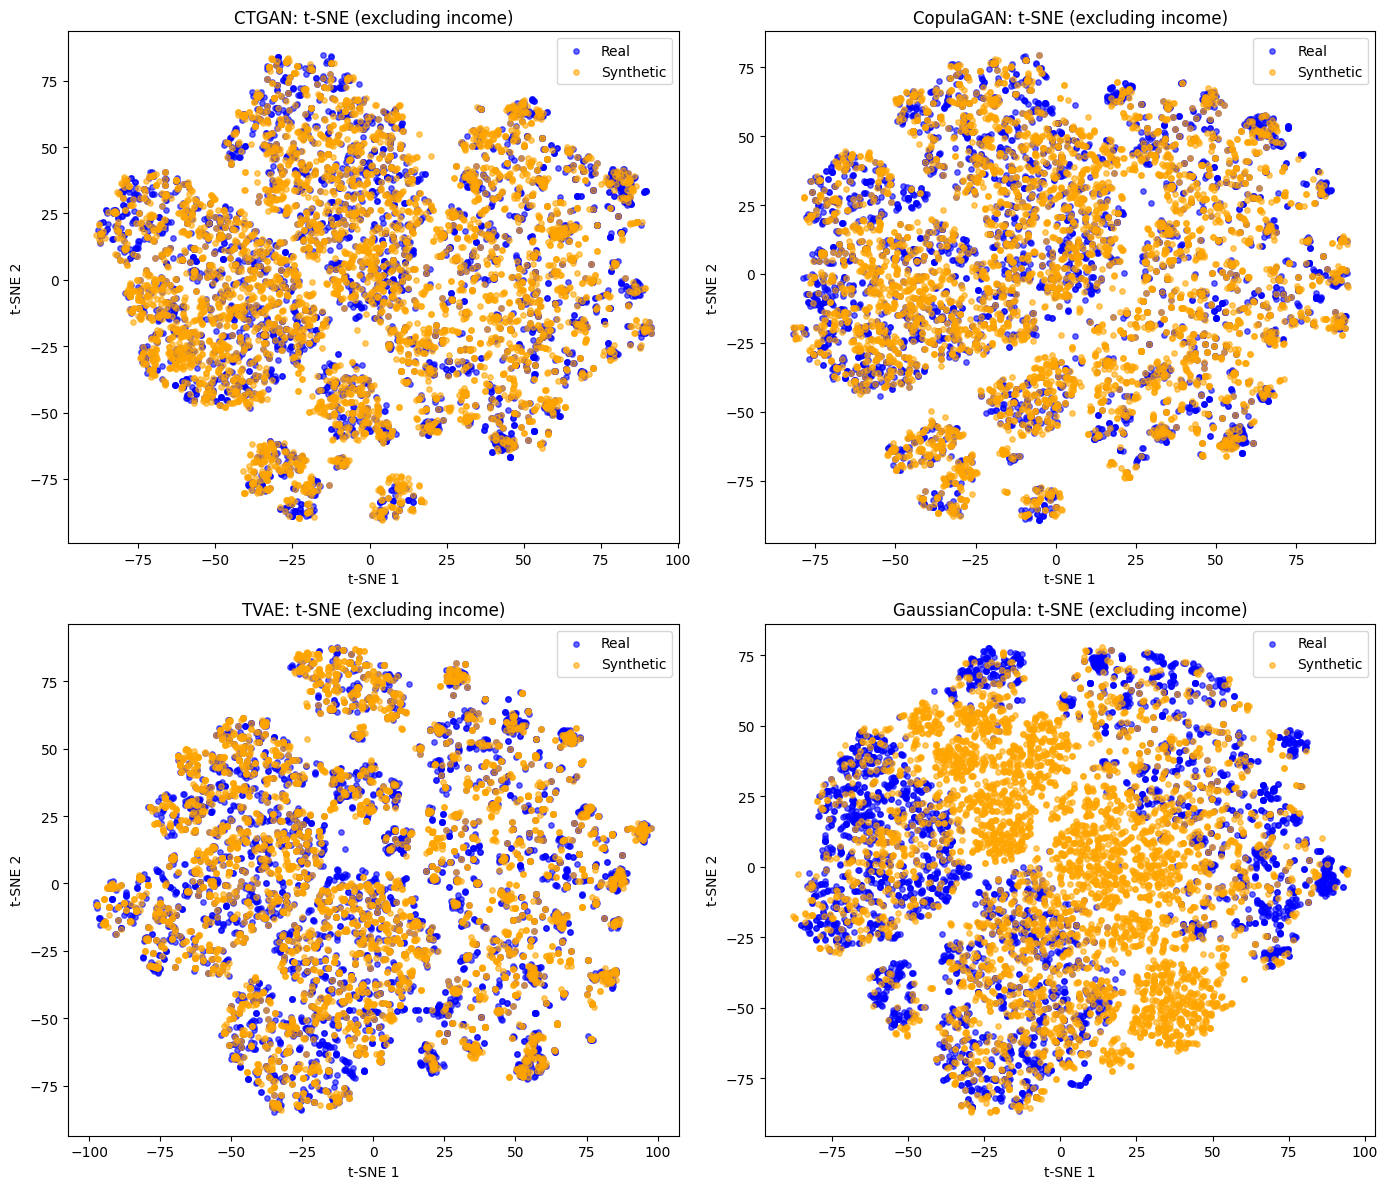

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - data: Adult Census real DataFrame
# - synthetic_datasets: dict with keys like "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Adult Census: usually exclude the label from "distribution overlap" plots
target_col = "income"     # change if your column name differs
id_col = None             # set to "ID" only if you truly have one

# t-SNE speed knob (recommended). Set None to try full data (often too slow/large).
max_rows = 5000
random_state = 42

assert "data" in globals(), "Expected `data` DataFrame"
assert "synthetic_datasets" in globals(), "Expected `synthetic_datasets` dict"

# Drop label/id (if present)
_drop = [c for c in [id_col, target_col] if c and (c in data.columns)]
real_base = data.drop(columns=_drop, errors="ignore").copy()

# One-hot encode categoricals so MinMaxScaler gets numeric input
real_oh = pd.get_dummies(real_base, dummy_na=True)


def prep_synth(synth_df: pd.DataFrame) -> pd.DataFrame:
    # Align to same raw columns as real (after drops)
    s = synth_df.reindex(columns=real_base.columns, fill_value=np.nan).copy()
    s_oh = pd.get_dummies(s, dummy_na=True)
    return s_oh.reindex(columns=real_oh.columns, fill_value=0)


# Scale real once (after encoding). Fit ONLY on real (matches your original intent).
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_oh),
    columns=real_oh.columns,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    if model_name not in synthetic_datasets:
        ax.axis("off")
        ax.set_title(f"{model_name}: missing in synthetic_datasets")
        continue

    synth_oh = prep_synth(synthetic_datasets[model_name])

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_oh),
        columns=real_scaled.columns,
    )

    r = real_scaled
    s = synthetic_scaled

    if max_rows is not None:
        if len(r) > max_rows:
            r = r.sample(n=max_rows, random_state=random_state)
        if len(s) > max_rows:
            s = s.sample(n=max_rows, random_state=random_state)

    combined = np.vstack([r.to_numpy(dtype=float, copy=False),
                          s.to_numpy(dtype=float, copy=False)])
    labels = np.array(["Real"] * len(r) + ["Synthetic"] * len(s), dtype=object)

    tsne = TSNE(
        n_components=2,
        random_state=random_state,
        learning_rate="auto",
        init="pca",          # usually more stable than init="random" for mixed/binary features
        perplexity=30,       # lower if you set max_rows much smaller (e.g., 200–500)
    )
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real",
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic",
    )

    ax.set_title(f"{model_name}: t-SNE (excluding {', '.join(_drop) if _drop else 'nothing'})")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

#### 1.6 MMD (Maximum Mean Discrepancy)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

# -----------------------------
# Adult Census settings
# -----------------------------
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "income"   # Adult label column
id_col = None           # set to "ID" only if you truly have one

max_rows = 2000
seed = 42

assert "data" in globals(), "Expected `data` DataFrame"
assert "synthetic_datasets" in globals(), "Expected `synthetic_datasets` dict"


def _sample_rows(X: np.ndarray, max_rows: int = 2000) -> np.ndarray:
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]


def _median_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    if take < 2:
        return 1.0

    idx = np.random.default_rng(seed).choice(n, size=take, replace=False)
    Zs = Z[idx]

    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    vals = vals[vals > 0]
    med = float(np.median(vals)) if vals.size else 1.0
    return 1.0 / (2.0 * med)


def compute_mmd_rbf_safe(X: np.ndarray, Y: np.ndarray, gamma: float | None = None) -> float:
    if gamma is None:
        gamma = _median_gamma(X, Y)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())


# Drop label/id (if present)
drop_cols = [c for c in [id_col, target_col] if c and (c in data.columns)]
real_df = data.drop(columns=drop_cols, errors="ignore").copy()

# One-hot encode categoricals (Adult has many categoricals)
real_oh = pd.get_dummies(real_df, dummy_na=True)

mmd_results = []

for model_name in model_order:
    if model_name not in synthetic_datasets:
        print(f"Skipping {model_name}: not found in synthetic_datasets")
        continue

    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    # Align raw columns first, then OHE with the same dummy layout as real
    synth_df = synth_df.reindex(columns=real_df.columns, fill_value=np.nan)
    synth_oh = pd.get_dummies(synth_df, dummy_na=True).reindex(columns=real_oh.columns, fill_value=0)

    X_real = real_oh.to_numpy(dtype=np.float64, copy=False)
    X_synth = synth_oh.to_numpy(dtype=np.float64, copy=False)

    # Safety: no NaNs allowed for StandardScaler
    if np.isnan(X_real).any() or np.isnan(X_synth).any():
        X_real = np.nan_to_num(X_real, nan=0.0, posinf=0.0, neginf=0.0)
        X_synth = np.nan_to_num(X_synth, nan=0.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=max_rows)
    Xs = _sample_rows(X_synth_scaled, max_rows=max_rows)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")

try:
    display(mmd_summary_df)
except NameError:
    print(mmd_summary_df.to_string(index=False))

CTGAN - MMD score: 0.016426
CopulaGAN - MMD score: 0.013831
TVAE - MMD score: 0.006875
GaussianCopula - MMD score: 0.080521

MMD comparison (lower is better):


,Model,MMD_Score
0,TVAE,0.006875
1,CopulaGAN,0.013831
2,CTGAN,0.016426
3,GaussianCopula,0.080521


#### 1.7 Cosine Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Adult Census defaults
target_col = "income"
id_col = None  # or "ID" if you truly have it

drop_cols = [c for c in [id_col, target_col] if c and (c in data.columns)]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_oh = pd.get_dummies(real_features, dummy_na=True)

similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    # align columns to real, then one-hot with same columns as real_oh
    synth_features = synth_features.reindex(columns=real_features.columns, fill_value=np.nan)
    synth_oh = pd.get_dummies(synth_features, dummy_na=True).reindex(columns=real_oh.columns, fill_value=0)

    X_real = real_oh.to_numpy(dtype=np.float64, copy=False)
    X_synth = synth_oh.to_numpy(dtype=np.float64, copy=False)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim,
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: -0.0004
Maximum cosine similarity: 1.0000

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: -0.0004
Maximum cosine similarity: 1.0000

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0052
Maximum cosine similarity: 1.0000

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: -0.0006
Maximum cosine similarity: 1.0000

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.005204,1.000000
1,CTGAN,-0.000376,1.000000
2,CopulaGAN,-0.000428,1.000000
3,GaussianCopula,-0.000576,0.999958


#### 1.8 Nearest Neighbours

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from IPython.display import display
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Adult Census defaults
target_col = "income"

rng = np.random.default_rng(random_state)

drop_cols = [c for c in [id_col, target_col] if c and (c in data.columns)]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_oh = pd.get_dummies(real_features, dummy_na=True)

privacy_rows = []

for model_name in model_order:
    if model_name not in synthetic_datasets:
        print(f"\nSkipping {model_name}: not found in synthetic_datasets")
        continue

    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    synth_features = synth_features.reindex(columns=real_features.columns, fill_value=np.nan)
    synth_oh = pd.get_dummies(synth_features, dummy_na=True).reindex(columns=real_oh.columns, fill_value=0)

    X_real = real_oh.to_numpy(dtype=np.float64, copy=False)
    X_synth = synth_oh.to_numpy(dtype=np.float64, copy=False)

    if np.isnan(X_real).any() or np.isnan(X_synth).any():
        X_real = np.nan_to_num(X_real, nan=0.0, posinf=0.0, neginf=0.0)
        X_synth = np.nan_to_num(X_synth, nan=0.0, posinf=0.0, neginf=0.0)

    if max_rows_real is not None and X_real.shape[0] > max_rows_real:
        X_real = X_real[rng.choice(X_real.shape[0], size=max_rows_real, replace=False)]
    if max_rows_synth is not None and X_synth.shape[0] > max_rows_synth:
        X_synth = X_synth[rng.choice(X_synth.shape[0], size=max_rows_synth, replace=False)]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1, algorithm="auto").fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check (Synthetic -> nearest Real):")
    print(f"Rows used: real={X_real_scaled.shape[0]}, synth={X_synth_scaled.shape[0]}")
    print(f"Average NN Distance: {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance: {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist,
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check (Synthetic -> nearest Real):
Rows used: real=800, synth=800
Average NN Distance: 6.2407
Minimum NN Distance: 0.2257
5th Percentile NN Distance: 0.6910

CopulaGAN - Privacy Check (Synthetic -> nearest Real):
Rows used: real=800, synth=800
Average NN Distance: 5.6893
Minimum NN Distance: 0.1276
5th Percentile NN Distance: 0.8277

TVAE - Privacy Check (Synthetic -> nearest Real):
Rows used: real=800, synth=800
Average NN Distance: 3.9162
Minimum NN Distance: 0.0375
5th Percentile NN Distance: 0.5620

GaussianCopula - Privacy Check (Synthetic -> nearest Real):
Rows used: real=800, synth=800
Average NN Distance: 8.3046
Minimum NN Distance: 1.0049
5th Percentile NN Distance: 3.3175

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,GaussianCopula,8.304646,1.004943,3.317507
1,CTGAN,6.240705,0.225715,0.691039
2,CopulaGAN,5.689285,0.127577,0.827712
3,TVAE,3.916226,0.037544,0.561968


# 2 Statsistics 

Average error by model (numeric columns only)


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,18.985418,4.012140,12.528519
1,CopulaGAN,14.992197,5.836849,13.210107
2,TVAE,17.725137,7.969681,22.447195
3,GaussianCopula,675.631093,0.304556,111.089745


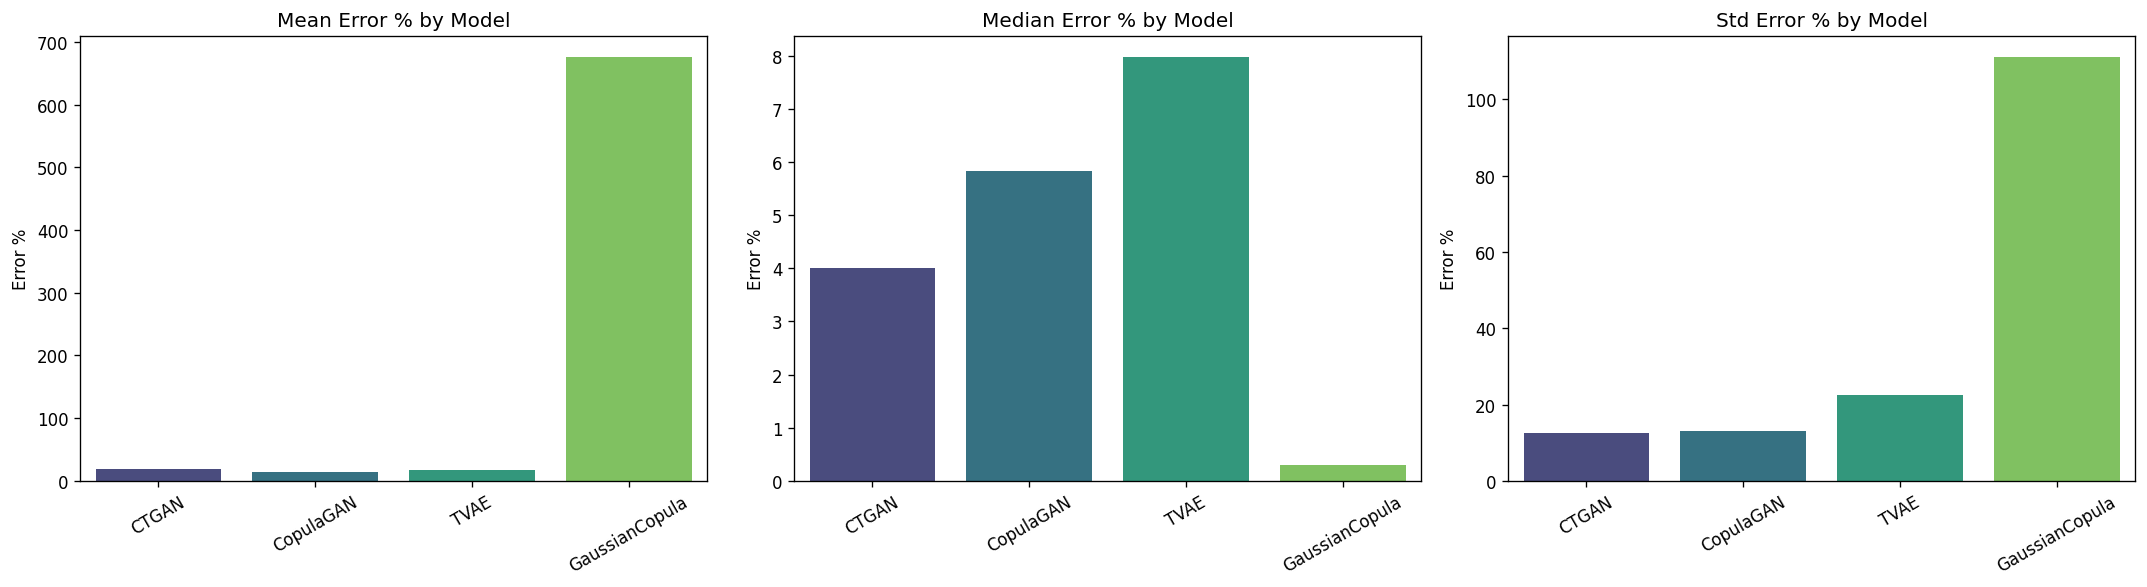

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Adult Census defaults
target_col = "income"   # usually categorical strings like "<=50K" / ">=50K"
id_col = "ID"         # set to None if you don't have an ID column

real_df = data.copy()

# Numeric columns only (Adult has many categorical string columns)
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# Drop ID + label from numeric comparisons (label is typically not numeric in Adult)
_drop = []
if id_col and (id_col in num_cols):
    _drop.append(id_col)
if target_col and (target_col in num_cols):
    _drop.append(target_col)

num_cols = [c for c in num_cols if c not in set(_drop)]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    if model_name not in synthetic_datasets:
        continue

    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100.0
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values,
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True)),
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").reindex(model_order).reset_index()

print("Average error by model (numeric columns only)")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", hue="Model", ax=axes[0], palette="viridis", legend=False)
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", hue="Model", ax=axes[1], palette="viridis", legend=False)
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", hue="Model", ax=axes[2], palette="viridis", legend=False)
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

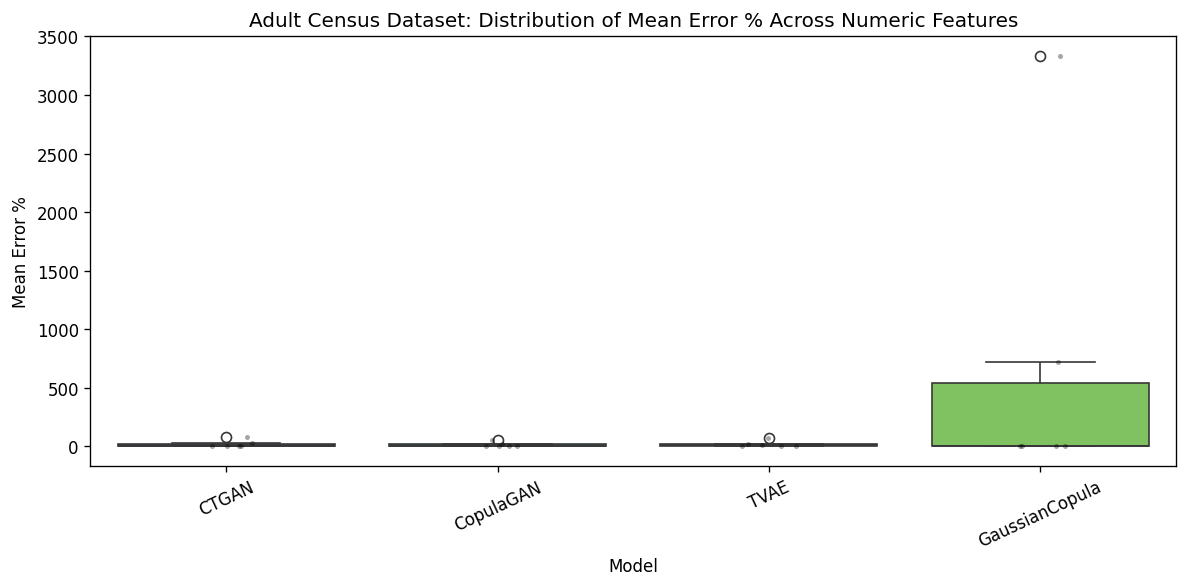

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_order
        if m in feature_error_by_model
    ],
    ignore_index=True,
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Adult Census Dataset: Distribution of Mean Error % Across Numeric Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

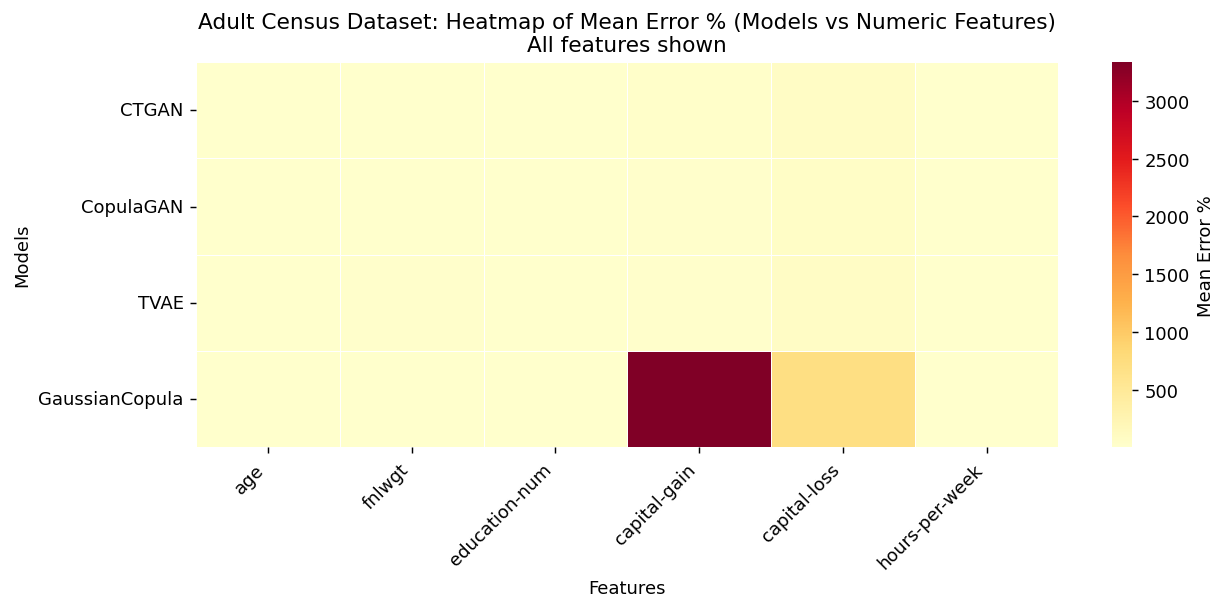

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame(
    {
        m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
        for m in model_order
        if m in feature_error_by_model
    }
).T.reindex([m for m in model_order if m in feature_error_by_model])

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"


def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[: max_len - 1] + "..."


display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"},
)

plt.title(
    f"Adult Census Dataset: Heatmap of Mean Error % (Models vs Numeric Features)\n{truncated_note}"
)
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

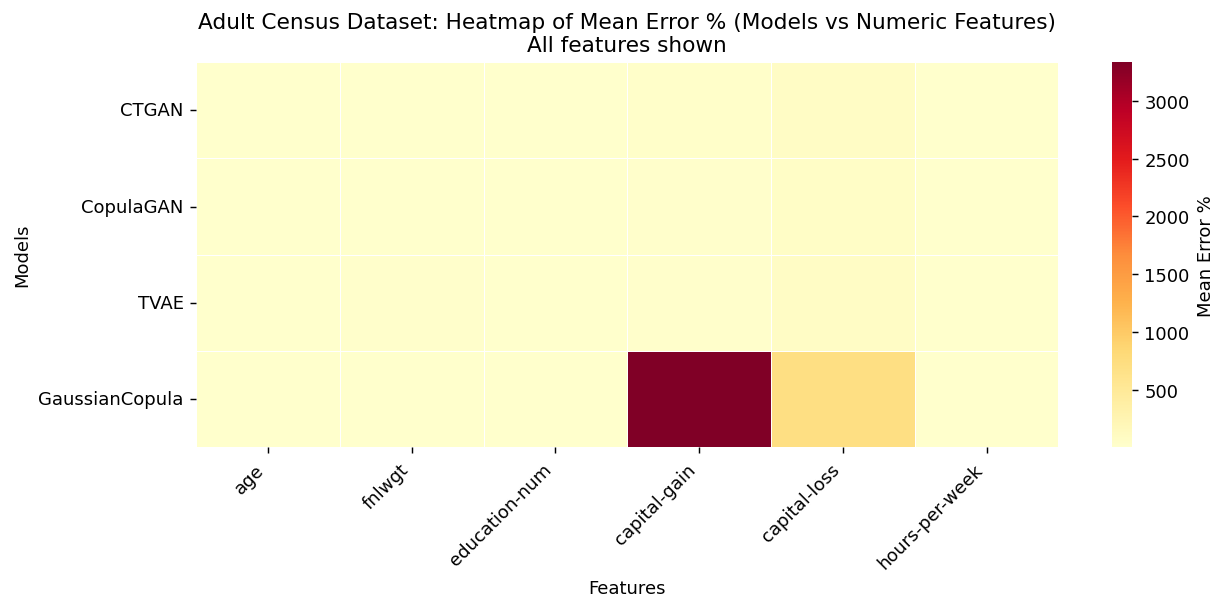

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame(
    {
        m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
        for m in model_order
        if m in feature_error_by_model
    }
).T.reindex([m for m in model_order if m in feature_error_by_model])

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"


def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[: max_len - 1] + "..."


display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"},
)

plt.title(
    f"Adult Census Dataset: Heatmap of Mean Error % (Models vs Numeric Features)\n{truncated_note}"
)
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3 Bivariate Analysis

In [ ]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np


def bivariate_quality_adult(real_df, synth_df, target="income", id_col=None):
    """
    Adult Census version:
    - Scales numeric columns with MinMaxScaler fit on REAL
    - Pairwise numeric Δ-correlation
    - If `target` exists in both frames, compares class-conditional 1D distributions
      using Wasserstein distance between the two income classes (expects 2 classes).
    """
    # numeric columns in real (baseline typing)
    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()

    # drop identifiers / label from numeric scaling list
    drop = {c for c in [target, id_col] if c}
    num_cols = [c for c in num_cols if c not in drop]

    scaler = MinMaxScaler()

    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    # align columns for scaling blocks that exist in both
    common_num = [c for c in num_cols if c in synth_scaled.columns]
    if not common_num:
        return (
            pd.DataFrame(columns=["var_a", "var_b", "delta_corr"]),
            pd.DataFrame(columns=["feature", "delta_wasserstein"]),
        )

    real_scaled[common_num] = scaler.fit_transform(real_df[common_num].apply(pd.to_numeric, errors="coerce"))
    synth_scaled[common_num] = scaler.transform(synth_df[common_num].apply(pd.to_numeric, errors="coerce"))

    results_corr = []
    results_target = []

    for a, b in combinations(common_num, 2):
        r_corr = real_scaled[[a, b]].corr(numeric_only=True).iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr(numeric_only=True).iloc[0, 1]

        # guard against NaN correlations (constant columns)
        r_corr = 0.0 if pd.isna(r_corr) else float(r_corr)
        s_corr = 0.0 if pd.isna(s_corr) else float(s_corr)

        results_corr.append({"var_a": a, "var_b": b, "delta_corr": abs(r_corr - s_corr)})

    if target in real_scaled.columns and target in synth_scaled.columns:
        # normalize labels to strings for stable grouping
        rt = real_scaled[target].astype(str)
        st = synth_scaled[target].astype(str)

        for col in common_num:
            rdf = pd.DataFrame({"y": rt, "x": pd.to_numeric(real_scaled[col], errors="coerce")}).dropna()
            sdf = pd.DataFrame({"y": st, "x": pd.to_numeric(synth_scaled[col], errors="coerce")}).dropna()

            r_groups = [g["x"].values for _, g in rdf.groupby("y")]
            s_groups = [g["x"].values for _, g in sdf.groupby("y")]

            if len(r_groups) == 2 and len(s_groups) == 2:
                d_real = stats.wasserstein_distance(*r_groups)
                d_synth = stats.wasserstein_distance(*s_groups)
                results_target.append({"feature": col, "delta_wasserstein": abs(d_real - d_synth)})

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = (
        pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)
        if results_target
        else pd.DataFrame(columns=["feature", "delta_wasserstein"])
    )

    return corr_df, target_df

In [ ]:
import pandas as pd
from IPython.display import display

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()

# Adult Census defaults
target_col = "income"
id_col = None  # set to "ID" only if you truly have an ID column

if "bivariate_quality_adult" not in globals():
    raise NameError("Define `bivariate_quality_adult` before running this cell.")

quality_fn = bivariate_quality_adult

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    real_eval = real_df.drop(columns=[c for c in [id_col] if c], errors="ignore")
    synth_eval = synth_df.drop(columns=[c for c in [id_col] if c], errors="ignore")

    corr_results, target_results = quality_fn(
        real_df=real_eval,
        synth_df=synth_eval,
        target=target_col,
        id_col=id_col,
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by {target_col} class:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = "delta_corr" if "delta_corr" in corr_results.columns else None
    target_metric_col = "delta_wasserstein" if "delta_wasserstein" in target_results.columns else None

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col and len(corr_results) else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col and len(corr_results) else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col and len(target_results) else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col and len(target_results) else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
1,age,education-num,0.061826
9,education-num,capital-gain,0.050122
12,capital-gain,capital-loss,0.048025
5,fnlwgt,education-num,0.042578
3,age,capital-loss,0.031886
8,fnlwgt,hours-per-week,0.029298
14,capital-loss,hours-per-week,0.025777
2,age,capital-gain,0.023222
4,age,hours-per-week,0.021171
10,education-num,capital-loss,0.020675


CTGAN - Features that differ most by income class:


,feature,delta_wasserstein
0,age,0.030688
4,capital-loss,0.023119
3,capital-gain,0.017240
2,education-num,0.015597
5,hours-per-week,0.010487
1,fnlwgt,0.008637



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
4,age,hours-per-week,0.055255
1,age,education-num,0.045250
2,age,capital-gain,0.042516
10,education-num,capital-loss,0.023363
0,age,fnlwgt,0.018834
14,capital-loss,hours-per-week,0.018823
3,age,capital-loss,0.014204
12,capital-gain,capital-loss,0.010665
11,education-num,hours-per-week,0.010198
9,education-num,capital-gain,0.005996


GaussianCopula - Features that differ most by income class:


,feature,delta_wasserstein
3,capital-gain,0.077837
2,education-num,0.062608
0,age,0.045310
5,hours-per-week,0.032283
4,capital-loss,0.013931
1,fnlwgt,0.001648


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.061826,0.035458,0.030688,0.017628
1,CopulaGAN,0.079603,0.040606,0.038516,0.016755
2,TVAE,0.209649,0.079253,0.058992,0.016800
3,GaussianCopula,0.055255,0.024510,0.077837,0.038936


# 4.  Multivariate Analysis 

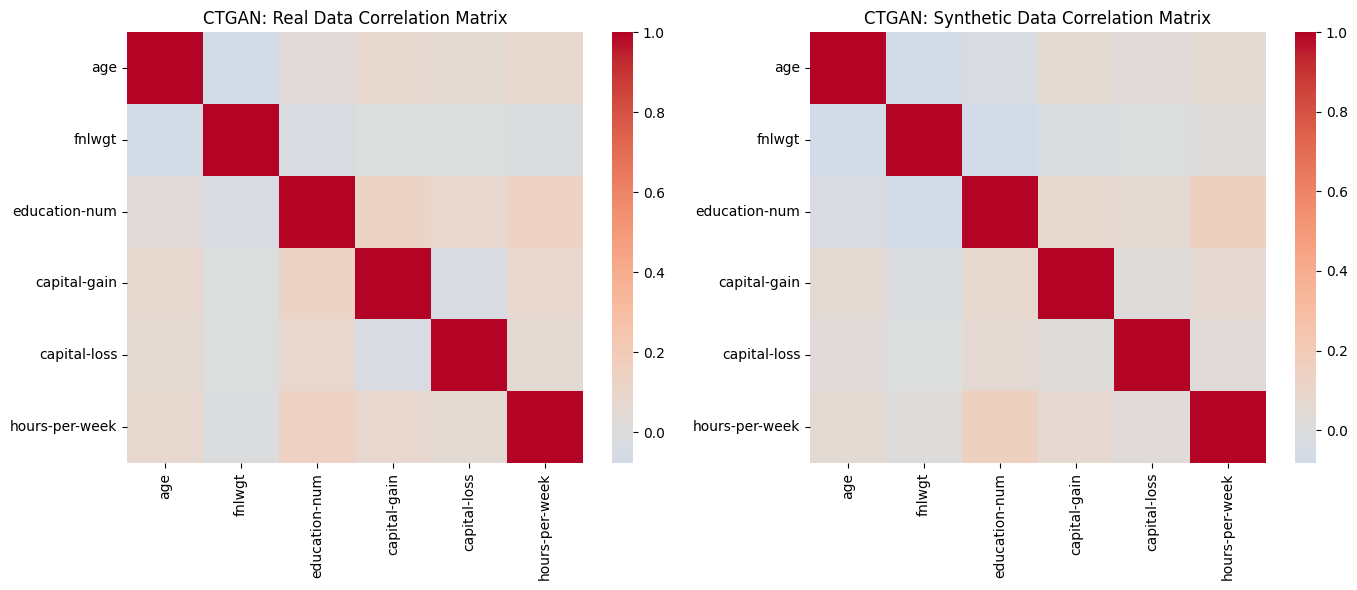

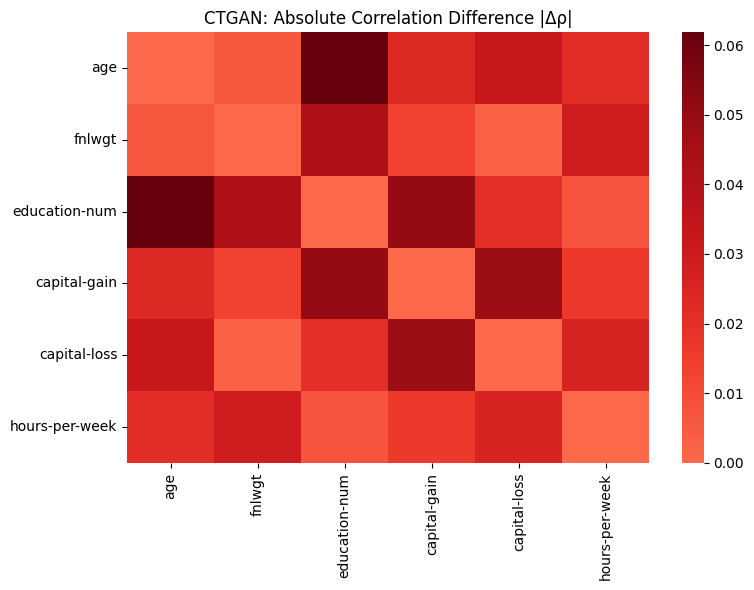

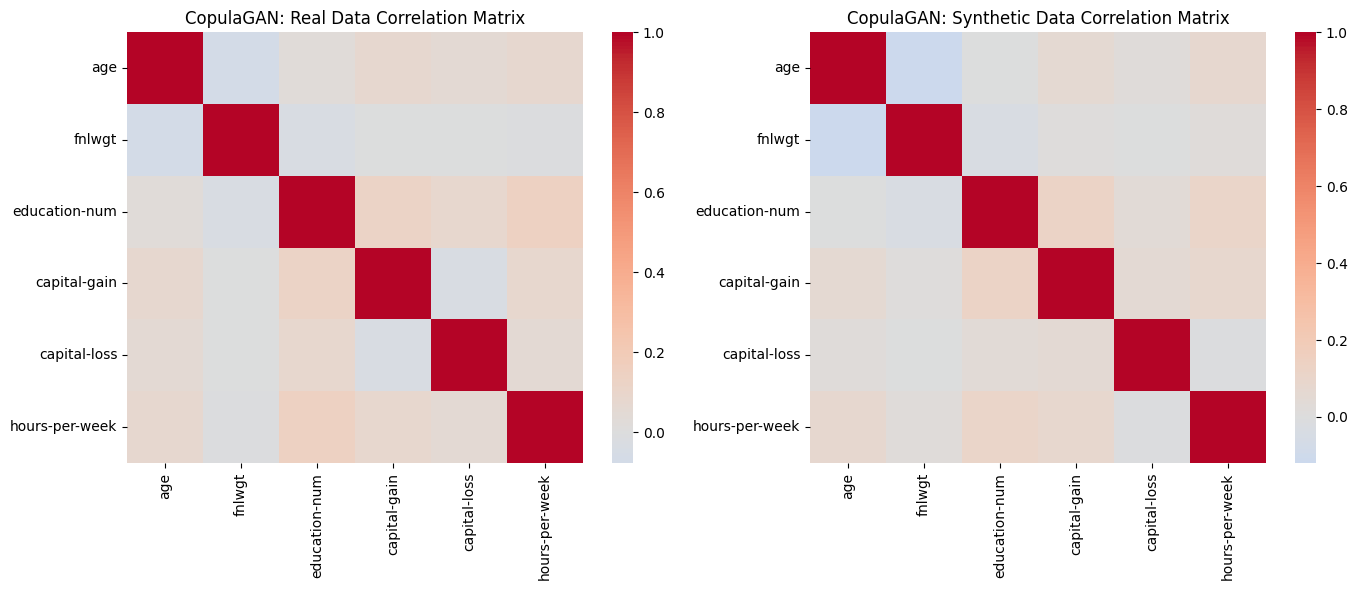

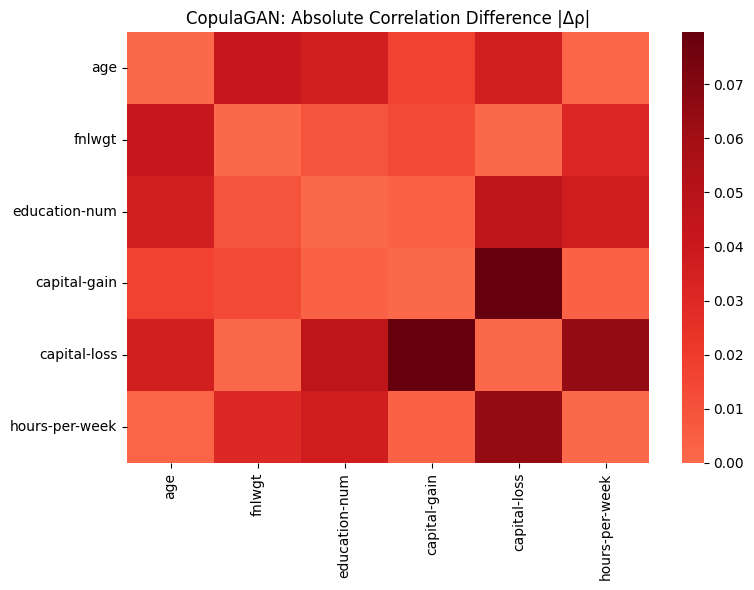

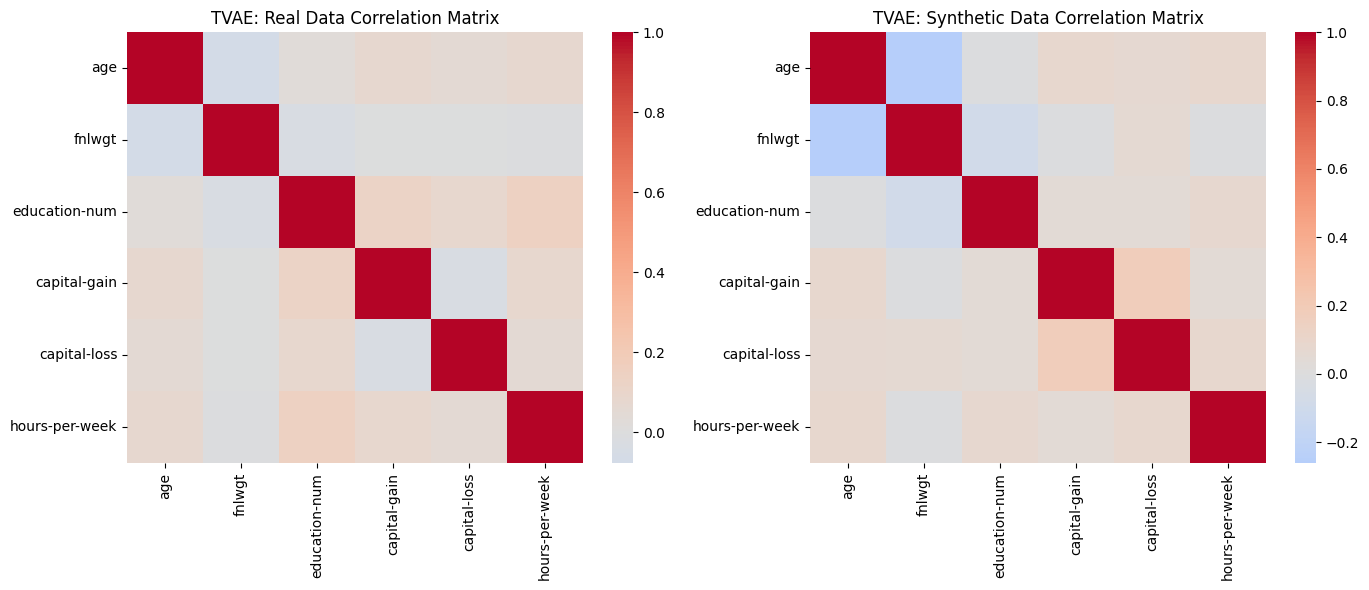

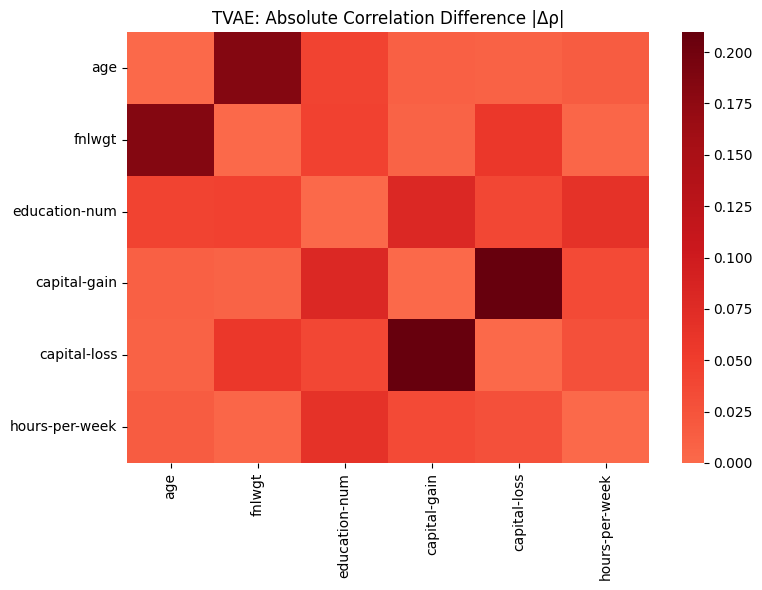

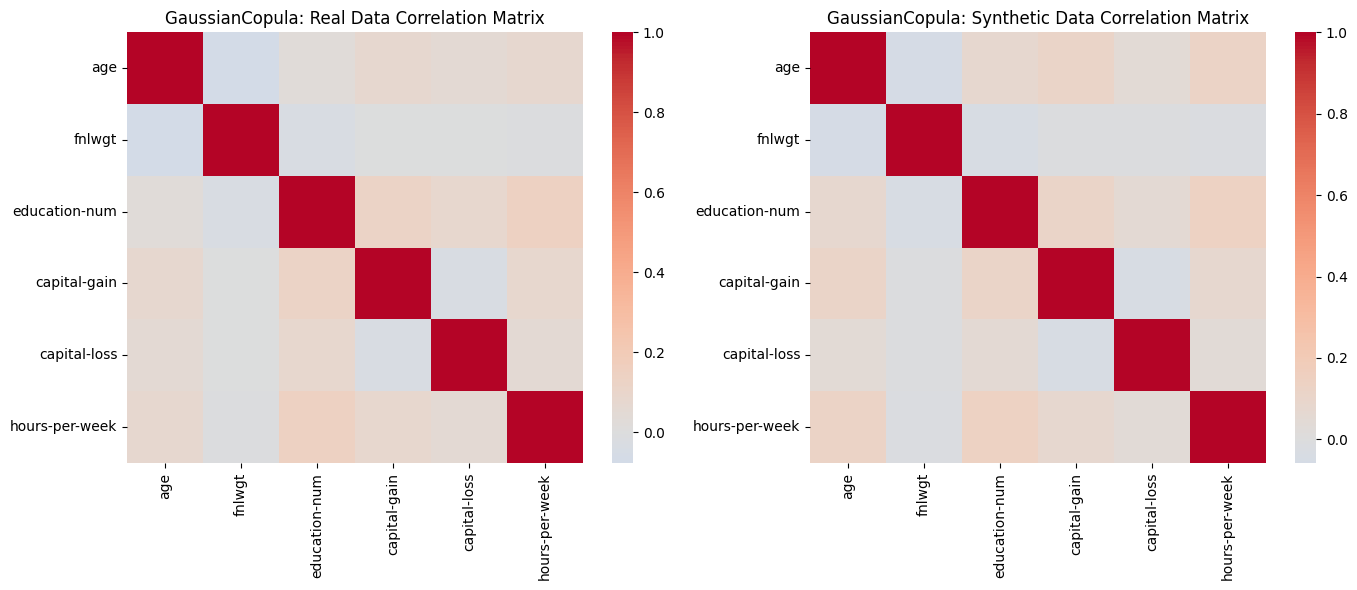

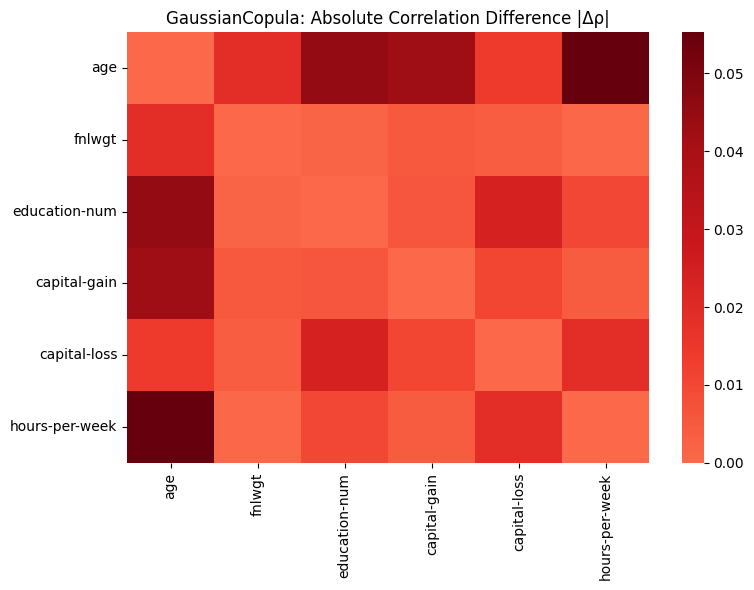

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()

# Adult Census defaults
target_col = "income"   # usually categorical strings; typically NOT in numeric corr matrix
id_col = None           # set to "ID" only if you truly have an ID column

# Correlation should be computed on numeric columns only
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

_drop = {c for c in [target_col, id_col] if c}
num_cols = [c for c in num_cols if c not in _drop]

# Coerce numeric columns defensively (some Adult CSVs store numeric-looking cols as object)
real_num = real_df[num_cols].apply(pd.to_numeric, errors="coerce")

real_corr = real_num.corr(numeric_only=True).fillna(0.0)

for model_name in model_order:
    if model_name not in synthetic_datasets:
        print(f"Skipping {model_name}: not found in synthetic_datasets")
        continue

    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    synth_num = synth_df[num_cols].apply(pd.to_numeric, errors="coerce")
    synth_corr = synth_num.corr(numeric_only=True).reindex(index=real_corr.index, columns=real_corr.columns).fillna(0.0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()


CTGAN - Global MMD (RBF, subsampled): 0.018062 (n_real=2500, n_synth=2500)


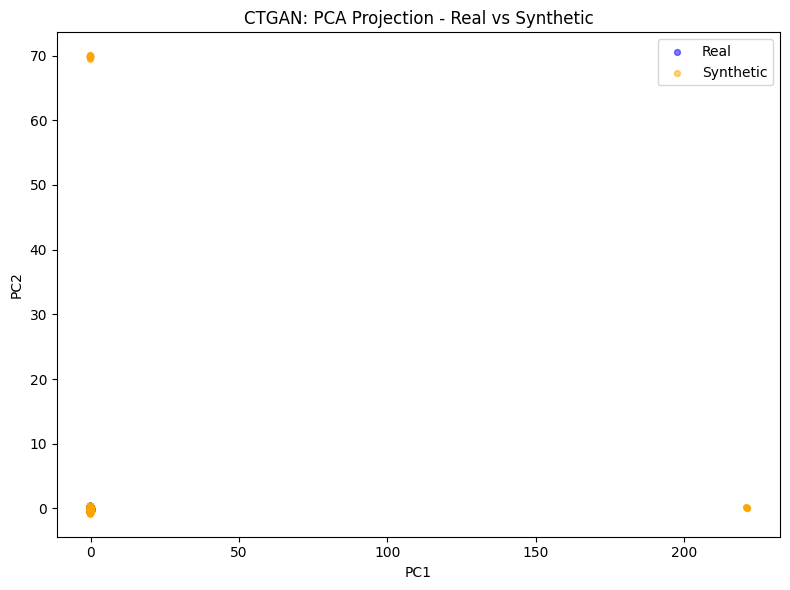

CTGAN - Two-Sample Classifier Accuracy: 0.8179 (n_real=4000, n_synth=4000, p=113)

CopulaGAN - Global MMD (RBF, subsampled): 0.012815 (n_real=2500, n_synth=2500)


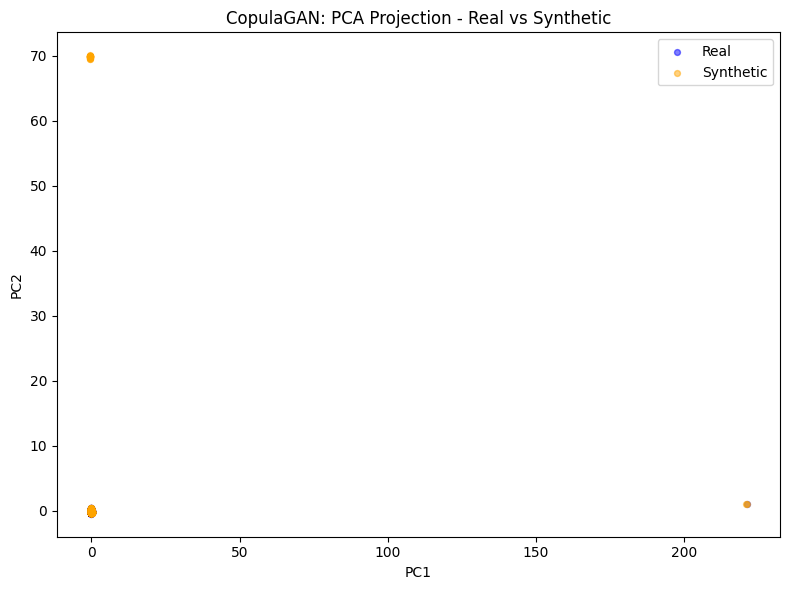

CopulaGAN - Two-Sample Classifier Accuracy: 0.7050 (n_real=4000, n_synth=4000, p=113)

TVAE - Global MMD (RBF, subsampled): 0.007210 (n_real=2500, n_synth=2500)


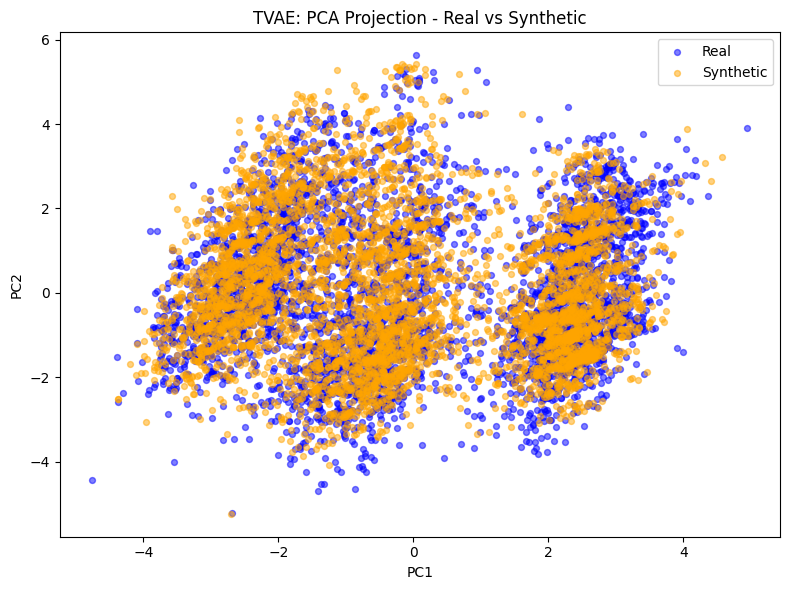

TVAE - Two-Sample Classifier Accuracy: 0.8037 (n_real=4000, n_synth=4000, p=113)

GaussianCopula - Global MMD (RBF, subsampled): 0.077847 (n_real=2500, n_synth=2500)


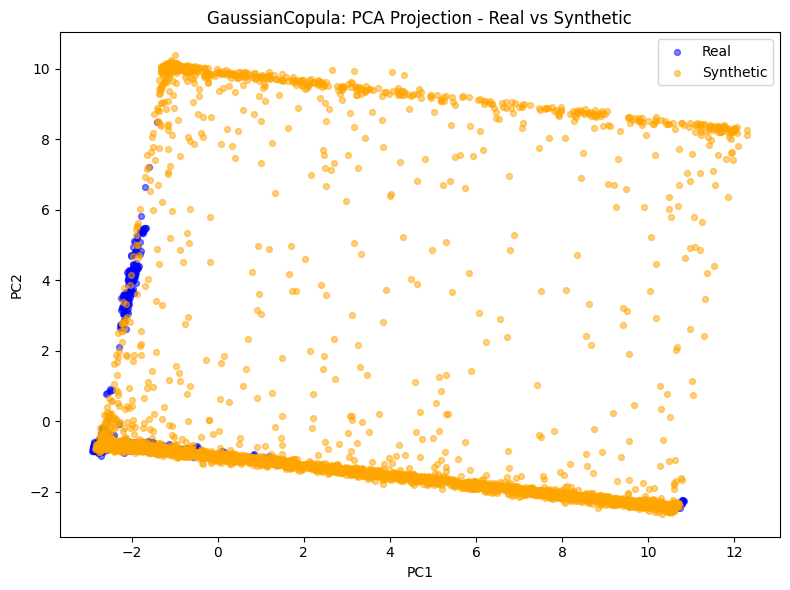

GaussianCopula - Two-Sample Classifier Accuracy: 0.9783 (n_real=4000, n_synth=4000, p=113)

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,TVAE,0.007210,0.803750
1,CopulaGAN,0.012815,0.705000
2,CTGAN,0.018062,0.817917
3,GaussianCopula,0.077847,0.978333


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500, rng=None):
    """
    Same estimator style as your cell, but fixes a footgun:
    do NOT put `np.random.default_rng(...)` in a default argument (it becomes shared/mutable).

    Notes:
    - Intended for SUBSAMPLED X/Y (otherwise kernel matrices explode).
    """
    if rng is None:
        rng = np.random.default_rng(42)

    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)

    n, m = len(X), len(Y)
    if n < 2 or m < 2:
        return float("nan")

    if gamma is None:
        Z = np.vstack([X, Y])
        k = min(int(gamma_sample_size), len(Z))
        idx = rng.choice(len(Z), size=k, replace=False)
        Zs = Z[idx]

        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        vals = vals[vals > 0]
        med = float(np.median(vals)) if vals.size else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    return float(
        (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
        + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
        - 2.0 * Kxy.mean()
    )


model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Adult Census defaults
target_col = "income"
id_col = None  # set to "ID" only if you truly have an ID column

# Adult-scale safety knobs (kernel MMD is O(n^2) memory)
mmd_sample = 2500
pca_sample = 5000
c2st_sample = 8000

# If one-hot expansion is very wide, RandomForest gets slow; compress for C2ST only
svd_components = 200
svd_threshold = 300  # if #columns > threshold, run TruncatedSVD on scaled matrix

random_state = 42
rng = np.random.default_rng(random_state)

drop_cols = [c for c in [id_col, target_col] if c and (c in data.columns)]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
X_real_oh = pd.get_dummies(X_real_df, dummy_na=True)

results = []

for model_name in model_order:
    if model_name not in synthetic_datasets:
        print(f"\nSkipping {model_name}: not found in synthetic_datasets")
        continue

    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    X_synth_df = X_synth_df.reindex(columns=X_real_df.columns, fill_value=np.nan)
    X_synth_oh = pd.get_dummies(X_synth_df, dummy_na=True).reindex(columns=X_real_oh.columns, fill_value=0)

    X_real = X_real_oh.to_numpy(dtype=np.float64, copy=False)
    X_synth = X_synth_oh.to_numpy(dtype=np.float64, copy=False)

    if np.isnan(X_real).any() or np.isnan(X_synth).any():
        X_real = np.nan_to_num(X_real, nan=0.0, posinf=0.0, neginf=0.0)
        X_synth = np.nan_to_num(X_synth, nan=0.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler(with_mean=True, with_std=True)
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # --- MMD on subsamples (memory safe) ---
    Xr_m = X_real_scaled
    Xs_m = X_synth_scaled
    if len(Xr_m) > mmd_sample:
        Xr_m = Xr_m[rng.choice(len(Xr_m), size=mmd_sample, replace=False)]
    if len(Xs_m) > mmd_sample:
        Xs_m = Xs_m[rng.choice(len(Xs_m), size=mmd_sample, replace=False)]

    mmd_value = mmd_rbf(Xr_m, Xs_m, rng=rng)
    print(f"\n{model_name} - Global MMD (RBF, subsampled): {mmd_value:.6f} (n_real={len(Xr_m)}, n_synth={len(Xs_m)})")

    # --- PCA plot (subsample for speed) ---
    Xr_p = X_real_scaled
    Xs_p = X_synth_scaled
    if len(Xr_p) > pca_sample:
        Xr_p = Xr_p[rng.choice(len(Xr_p), size=pca_sample, replace=False)]
    if len(Xs_p) > pca_sample:
        Xs_p = Xs_p[rng.choice(len(Xs_p), size=pca_sample, replace=False)]

    pca = PCA(n_components=2, random_state=random_state)
    X_all = np.vstack([Xr_p, Xs_p])
    labels = np.array(["Real"] * len(Xr_p) + ["Synthetic"] * len(Xs_p), dtype=object)
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1], color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1], color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- C2ST (subsample for speed, keep class balance) ---
    Xr_c = X_real_scaled
    Xs_c = X_synth_scaled

    half = c2st_sample // 2
    if len(Xr_c) > half:
        Xr_c = Xr_c[rng.choice(len(Xr_c), size=half, replace=False)]
    if len(Xs_c) > half:
        Xs_c = Xs_c[rng.choice(len(Xs_c), size=half, replace=False)]

    # Optional dimensionality reduction for RF speed on wide one-hot matrices
    if Xr_c.shape[1] > svd_threshold:
        svd = TruncatedSVD(n_components=min(svd_components, Xr_c.shape[1] - 1), random_state=random_state)
        X_c2st = np.vstack([svd.fit_transform(Xr_c), svd.transform(Xs_c)])
    else:
        X_c2st = np.vstack([Xr_c, Xs_c])

    y_c2st = np.hstack([np.ones(len(Xr_c)), np.zeros(len(Xs_c))])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=random_state
    )

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1,
        max_depth=None,
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f} (n_real={len(Xr_c)}, n_synth={len(Xs_c)}, p={X_c2st.shape[1]})")

    results.append({"Model": model_name, "Global_MMD_RBF": float(mmd_value), "C2ST_Accuracy": float(acc)})

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)

# 5 Utility with 10 classifiers

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


models = { 
    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}


def income_to_binary(y):
    s = y.astype("string").str.strip()
    s = s.str.replace(r"\.$", "", regex=True)
    s = s.str.replace(r"(?i)50k", "50K", regex=True)
    return np.where(s.str.contains(">50K", case=False), 1, 0)


def build_preprocessor(df, label_col):
    X = df.drop(columns=[label_col])
    cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    return ColumnTransformer([
        ("cat", cat_pipe, cat_cols),
        ("num", num_pipe, num_cols)
    ])


def evaluate_models(train_df, test_df, label_col, models, test_size=0.2, seed=42):
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df[label_col] = income_to_binary(train_df[label_col])
    test_df[label_col]  = income_to_binary(test_df[label_col])

    train_df = train_df.dropna(subset=[label_col])
    test_df  = test_df.dropna(subset=[label_col])

    train_df[label_col] = train_df[label_col].astype(int)
    test_df[label_col]  = test_df[label_col].astype(int)

    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    preprocessor = build_preprocessor(train_df, label_col)

    rows = []
    for name, clf in models.items():
        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", clf)
        ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)

        if hasattr(pipe, "predict_proba"):
            y_prob = pipe.predict_proba(X_test)[:, 1]
        elif hasattr(pipe, "decision_function"):
            scores = pipe.decision_function(X_test)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

In [39]:
import pandas as pd

label_col = "income"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    synth_train = synthetic_datasets[synth_name][data.columns].copy()

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=data,
        label_col=label_col,
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (combined_comparison
           .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
           .mean()
           .sort_values("AUC_Drop"))

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)